# 0. Data Loading


In [2]:
import pandas as pd
import numpy as np
import shap
import joblib
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.preprocessing import *
from src.visualization import *
from src.metrics import *
from src.models import *

surge_pressures = pd.read_parquet("../data/surge_pressures.parquet")


/Users/leonardolorenzon/Desktop/Uni/Tesi/Progetto/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
surge_pressures.info()

<class 'pandas.DataFrame'>
MultiIndex: 8772000 entries, (np.float64(30.75), np.float64(-19.75), Timestamp('2019-01-01 01:00:00')) to (np.float64(59.75), np.float64(29.25), Timestamp('2024-12-31 22:00:00'))
Data columns (total 8 columns):
 #   Column      Dtype         
---  ------      -----         
 0   valid_time  datetime64[ns]
 1   msl         float32       
 2   msl_lag1d   float32       
 3   msl_lag2d   float32       
 4   msl_lag3d   float32       
 5   msl_lag4d   float32       
 6   msl_lag5d   float32       
 7   surge       float64       
dtypes: datetime64[ns](1), float32(6), float64(1)
memory usage: 368.1 MB


In [4]:
surge_pressures.tail(10)

valid_time          msl  \
latitude longitude time                                                   
59.75    20.25     2024-12-31 22:00:00 2024-12-31 22:00:00  100483.6875   
         21.25     2024-12-31 22:00:00 2024-12-31 22:00:00  100566.4375   
         22.25     2024-12-31 22:00:00 2024-12-31 22:00:00  100643.1875   
         23.25     2024-12-31 22:00:00 2024-12-31 22:00:00  100705.4375   
         24.25     2024-12-31 22:00:00 2024-12-31 22:00:00  100742.4375   
         25.25     2024-12-31 22:00:00 2024-12-31 22:00:00  100753.6875   
         26.25     2024-12-31 22:00:00 2024-12-31 22:00:00  100759.9375   
         27.25     2024-12-31 22:00:00 2024-12-31 22:00:00  100770.6875   
         28.25     2024-12-31 22:00:00 2024-12-31 22:00:00  100777.9375   
         29.25     2024-12-31 22:00:00 2024-12-31 22:00:00  100752.9375   

                                         msl_lag1d  msl_lag2d   msl_lag3d  \
latitude longitude time                                                     
59.75    20.25     2024-12-31 22:00:00  100940.875  101079.50  100965.125   
         21.25     2024-12-31 22:00:00  100926.375  101047.25  100875.125   
         22.25     2024-12-31 22:00:00  100922.625  100996.50  100785.875   
         23.25     2024-12-31 22:00:00  100922.375  100948.75  100738.375   
         24.25     2024-12-31 22:00:00  100906.625  100896.00  100689.375   
         25.25     2024-12-31 22:00:00  100871.625  100832.75  100621.875   
         26.25     2024-12-31 22:00:00  100823.625  100757.75  100548.625   
         27.25     2024-12-31 22:00:00  100766.875  100666.50  100463.875   
         28.25     2024-12-31 22:00:00  100724.125  100580.25  100393.125   
         29.25     2024-12-31 22:00:00  100645.375  100497.50  100312.875   

                                        msl_lag4d  msl_lag5d     surge  
latitude longitude time                                                 
59.75    20.25     2024-12-31 22:00:00  100916.50  100736.25 -0.023471  
         21.25     2024-12-31 22:00:00  100834.25  100643.00 -0.023471  
         22.25     2024-12-31 22:00:00  100755.25  100560.50 -0.023471  
         23.25     2024-12-31 22:00:00  100679.25  100492.50 -0.023471  
         24.25     2024-12-31 22:00:00  100614.50  100437.00 -0.023471  
         25.25     2024-12-31 22:00:00  100536.25  100379.00 -0.023471  
         26.25     2024-12-31 22:00:00  100451.25  100316.50 -0.023471  
         27.25     2024-12-31 22:00:00  100378.75  100249.25 -0.023471  
         28.25     2024-12-31 22:00:00  100327.50  100200.50 -0.023471  
         29.25     2024-12-31 22:00:00  100254.00  100131.50 -0.023471

# 1. Exploratory Data Analysis: Dataset Structure

## 1.1 Dataset dimensions, data types, and index


In [5]:
print_dataset_structure(surge_pressures, "surge_pressures")

  Dataset: surge_pressures
  Shape (rows, columns): (8772000, 8)
  N. rows: 8,772,000
  N. columns: 8

  --- Indexes per row ---
  [0] latitude     dtype=float64  range=[30.75, 59.75]  unique=30
  [1] longitude    dtype=float64  range=[-19.75, 29.25]  unique=50
  [2] time         dtype=datetime64[ns]  range=[2019-01-01 01:00:00, 2024-12-31 22:00:00]  unique=5848

  --- Columns ---
  valid_time     dtype=datetime64[ns]
  msl            dtype=float32
  msl_lag1d      dtype=float32
  msl_lag2d      dtype=float32
  msl_lag3d      dtype=float32
  msl_lag4d      dtype=float32
  msl_lag5d      dtype=float32
  surge          dtype=float64



## 1.2 Missing values

Missing values — surge_pressures
Column                Count        %
--------------------------------------
valid_time                0    0.00%
msl                 467,840    5.33%
msl_lag1d           469,260    5.35%
msl_lag2d           470,680    5.37%
msl_lag3d           472,100    5.38%
msl_lag4d           473,520    5.40%
msl_lag5d           474,940    5.41%
surge                     0    0.00%

Total cells: 70,176,000
Total NaN: 2,828,340  (4.03%)



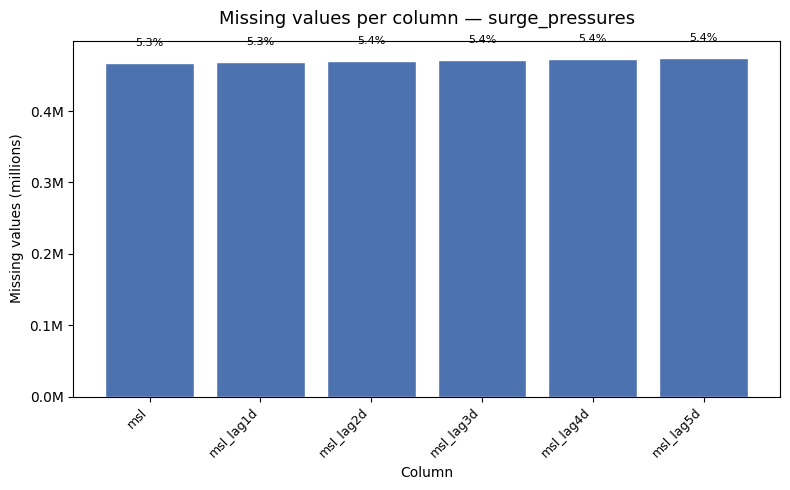

In [6]:
plot_missing(surge_pressures, "surge_pressures", "plots/surge/missing_surge.png")

## 1.3 Spatial grid uniformity


In [7]:
lats_sur, lons_sur = check_grid(surge_pressures, "surge_pressures")

Spatial grid — surge_pressures
  Unique latitudes:   30  range [30.75, 59.75]
  Unique longitudes:  50  range [-19.75, 29.25]
  Total grid points: 1500

  Spacing lat — min=1.0000  max=1.0000  std=0.000000  uniform=True
  Spacing lon — min=1.0000  max=1.0000  std=0.000000  uniform=True



## 1.4 Interactive spatial grid map


In [8]:
grid_lats, grid_lons = np.meshgrid(lats_sur, lons_sur)
grid_lats = grid_lats.ravel()
grid_lons = grid_lons.ravel()

plot_spatial_grid_map(
    grid_lats, grid_lons,
    venice_lat=45.44, venice_lon=12.33,
    venice_grid_lat=45.75, venice_grid_lon=12.25,
    title="Spatial grid — Europe and Mediterranean",
    save_path="plots/grid_map.png",
    n_grid_points=len(grid_lats),
)

# 2. Data Preprocessing and Train/Test Split

## 2.1 Feature matrix construction

In [9]:
sp_wide, y_surge = build_surge_features(
    surge_pressures,
    lat_min=38, lat_max=47,
    lon_min=7, lon_max=22,
    target_lat=45.75, target_lon=12.25,
)

=== surge_pressures — Preprocessing ===

[0] Original:  8,772,000 rows
[1] Adriatic area:  789,480 rows  (9 lat * 15 lon = 135 theoretical points)
[2] Drop NaN:  777,119 rows  (removed 12,361)
[3] Complete grid points:  777,119 rows  (133 points — excluded 2: {(44.75, 8.25), (44.75, 16.25)})
[4] Target y_surge:  5,843 time steps
[5] Pivot (wide):  5,843 rows * 798 columns  (6 features * 133 points)
    NaN after pivot:  0


In [10]:
sp_wide.head(5)

,msl_lat38.75_lon7.25,msl_lat38.75_lon8.25,msl_lat38.75_lon9.25,msl_lat38.75_lon10.25,msl_lat38.75_lon11.25,msl_lat38.75_lon12.25,msl_lat38.75_lon13.25,msl_lat38.75_lon14.25,msl_lat38.75_lon15.25,msl_lat38.75_lon16.25,...,msl_lag5d_lat46.75_lon12.25,msl_lag5d_lat46.75_lon13.25,msl_lag5d_lat46.75_lon14.25,msl_lag5d_lat46.75_lon15.25,msl_lag5d_lat46.75_lon16.25,msl_lag5d_lat46.75_lon17.25,msl_lag5d_lat46.75_lon18.25,msl_lag5d_lat46.75_lon19.25,msl_lag5d_lat46.75_lon20.25,msl_lag5d_lat46.75_lon21.25
time,,,,,,,,,,,,,,,,,,,,,
2019-01-01 16:00:00,102697.1875,102646.9375,102602.4375,102543.1875,102450.4375,102415.6875,102335.4375,102249.9375,102145.6875,102039.6875,...,103156.6875,103064.1875,103118.9375,103259.4375,103243.9375,103238.9375,103217.6875,103141.9375,103078.4375,103034.1875
2019-01-01 19:00:00,102709.9375,102668.1875,102613.4375,102583.1875,102495.1875,102465.9375,102389.9375,102298.1875,102179.4375,102105.6875,...,103065.9375,102995.9375,103061.9375,103145.4375,103134.6875,103091.6875,103066.1875,103042.6875,102990.6875,102945.1875
2019-01-01 22:00:00,102571.5000,102485.7500,102407.5000,102371.0000,102342.7500,102310.7500,102281.7500,102218.0000,102113.5000,102064.0000,...,102978.1250,102946.1250,102997.6250,103000.1250,103023.3750,103002.1250,102963.3750,102945.6250,102927.8750,102916.1250
2019-01-02 01:00:00,102465.3125,102363.8125,102231.3125,102142.5625,102118.5625,102097.3125,102089.5625,102048.8125,101972.5625,101910.0625,...,102713.0000,102669.2500,102763.0000,102729.5000,102758.0000,102808.0000,102823.0000,102819.0000,102795.2500,102784.2500
2019-01-02 04:00:00,102267.4375,102149.9375,102026.4375,101907.9375,101852.9375,101872.9375,101851.6875,101855.4375,101811.6875,101767.9375,...,102452.6250,102324.3750,102350.3750,102346.1250,102405.3750,102471.6250,102495.8750,102478.1250,102470.3750,102520.8750


In [11]:
y_surge.head(5)

time
2019-01-01 16:00:00   -0.036275
2019-01-01 19:00:00   -0.025217
2019-01-01 22:00:00   -0.014193
2019-01-02 01:00:00   -0.005779
2019-01-02 04:00:00   -0.001161
Name: surge, dtype: float64

## 2.2 Adriatic prediction domain

In [12]:
import re as _re

_pat = _re.compile(r'^.+_lat([\d.\-]+)_lon([\d.\-]+)$')
_pts = set()
for _col in sp_wide.columns:
    _m = _pat.match(_col)
    if _m:
        _pts.add((float(_m.group(1)), float(_m.group(2))))

_adria_lats = np.array([p[0] for p in _pts])
_adria_lons = np.array([p[1] for p in _pts])

plot_spatial_grid_map(
    _adria_lats, _adria_lons,
    venice_lat=45.44, venice_lon=12.33,
    venice_grid_lat=45.75, venice_grid_lon=12.25,
    title='Adriatic sub-grid — surge prediction domain',
    save_path='plots/surge/adriatic_grid_map.png',
    lon_range=(8, 24),
    lat_range=(36, 49),
    n_grid_points=len(_pts),
)

## 2.3 Chronological split (80/20)

In [13]:
(   X_surge_train, X_surge_test,
    y_surge_train, y_surge_test,
    split_surge,
) = temporal_split(sp_wide, y_surge)

 TEMPORAL SPLIT — 80% train | 20% test (chronological order)

  Split point:  2024-08-07 22:00:00
  Train: X=(4674, 798)  y = 4,674
  period: 2019-01-01 16:00:00  -> 2024-08-07 19:00:00

  Test: X=(1169, 798)  y = 1,169
  period: 2024-08-07 22:00:00  -> 2024-12-31 22:00:00



# 3. Exploratory Data Analysis: Target Variable

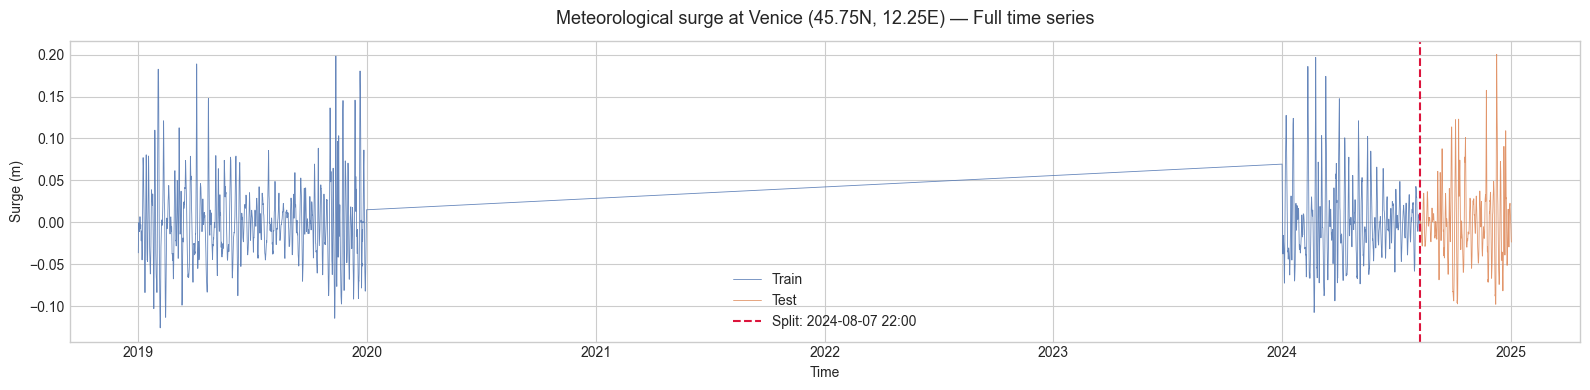

In [14]:
plot_target_timeseries(
    y_surge_train, y_surge_test, split_surge,
    title='Meteorological surge at Venice (45.75N, 12.25E) — Full time series',
    ylabel='Surge (m)',
    save_path='plots/surge/surge_timeseries.png',
    split_date_fmt='%Y-%m-%d %H:%M',
)

## 3.1 Descriptive statistics

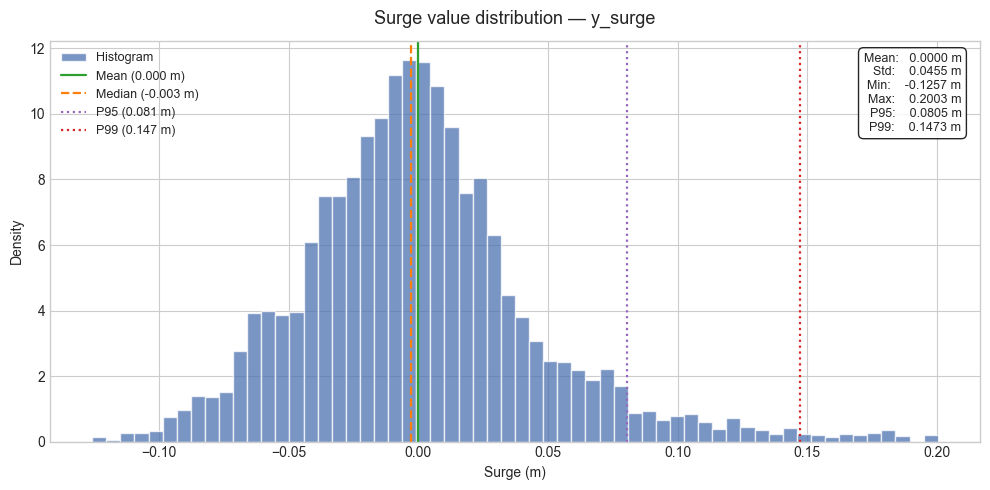

In [15]:
mean_s   = y_surge.mean()
median_s = y_surge.median()
std_s    = y_surge.std()
min_s    = y_surge.min()
max_s    = y_surge.max()
p95_s    = y_surge.quantile(0.95)
p99_s    = y_surge.quantile(0.99)

stat_lines = [
    (mean_s,   f'Mean ({mean_s:.3f} m)',     '#2ca02c', '-'),
    (median_s, f'Median ({median_s:.3f} m)', '#ff7f0e', '--'),
    (p95_s,    f'P95 ({p95_s:.3f} m)',       '#9467bd', ':'),
    (p99_s,    f'P99 ({p99_s:.3f} m)',       '#d62728', ':'),
]
plot_target_distribution(
    y_surge, stat_lines,
    title='Surge value distribution — y_surge',
    xlabel='Surge (m)',
    save_path='plots/surge/surge_distribution.png',
)

## 3.2 Seasonality

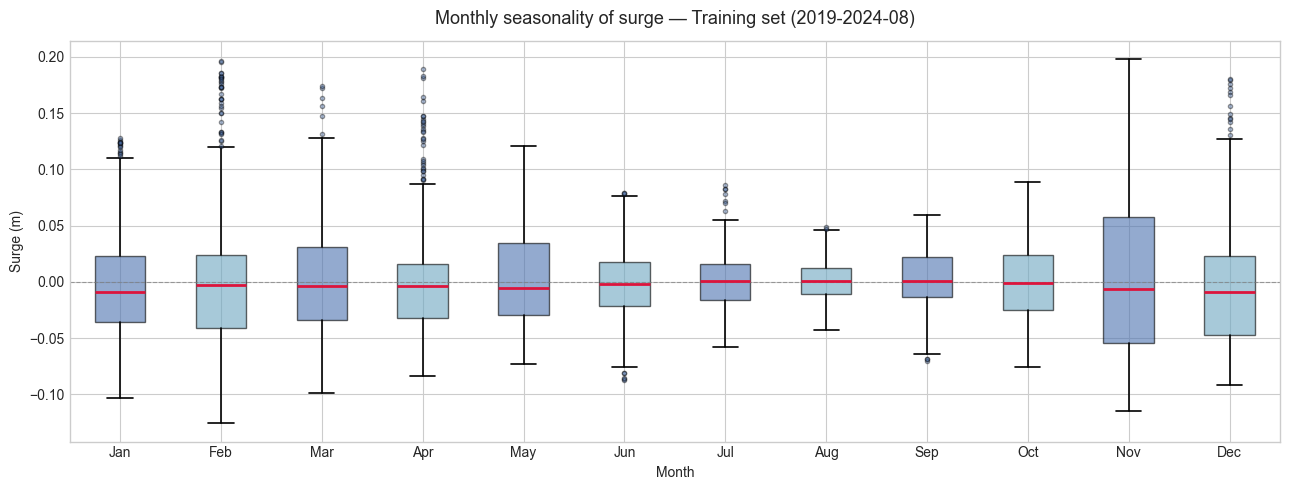

In [16]:
plot_monthly_boxplot(
    y_surge_train,
    title='Monthly seasonality of surge — Training set (2019-2024-08)',
    ylabel='Surge (m)',
    save_path='plots/surge/surge_monthly_boxplot.png',
)

## 3.3 Outlier analysis

In [17]:
# P99
outliers = y_surge[y_surge > p99_s]

print('=== Outlier analysis y_surge (values > P99) ===')
print(f'  P99 threshold: {p99_s:.4f} m')
print(f'  N. outliers: {len(outliers):,}')
print(f'  Percentage of total: {len(outliers)/len(y_surge)*100:.2f}%')
print(f'  Minimum outlier value: {outliers.min():.4f} m')
print(f'  Maximum outlier value: {outliers.max():.4f} m')

print()

print('  Top 10 most extreme values:')
print(f'  {"Date":<25} {"Surge (m)":>12}')
print('  ' + '-' * 38)
for ts, val in outliers.nlargest(10).items():
    print(f'  {str(ts):<25} {val:>12.4f}')

=== Outlier analysis y_surge (values > P99) ===
  P99 threshold: 0.1473 m
  N. outliers: 59
  Percentage of total: 1.01%
  Minimum outlier value: 0.1474 m
  Maximum outlier value: 0.2003 m

  Top 10 most extreme values:
  Date                         Surge (m)
  --------------------------------------
  2024-12-08 13:00:00             0.2003
  2024-12-08 10:00:00             0.1996
  2019-11-12 22:00:00             0.1982
  2019-11-12 19:00:00             0.1974
  2024-02-23 16:00:00             0.1966
  2024-02-23 13:00:00             0.1950
  2019-04-04 19:00:00             0.1889
  2024-12-08 16:00:00             0.1888
  2024-02-11 04:00:00             0.1859
  2024-02-23 19:00:00             0.1855


# 4.  XGBoost Model

## 4.1 Baseline model training

In [18]:
model_baseline = train_xgb_baseline(X_surge_train, y_surge_train)

Training complete


## 4.2 Baseline performance metrics

In [19]:
y_pred_train = model_baseline.predict(X_surge_train)
y_pred_test  = model_baseline.predict(X_surge_test)

metrics_train = compute_metrics(y_surge_train, y_pred_train, 'Train')
metrics_test  = compute_metrics(y_surge_test,  y_pred_test,  'Test')

print_metrics_table([metrics_train, metrics_test], title='METRICS — XGBoost Baseline')


  METRICS — XGBoost Baseline
  Set                       MAE (m)   RMSE (m)       R²
  ----------------------------------------------------
  Train                     0.00132    0.00176   0.9985
  Test                      0.02780    0.03689   0.3150


## 4.3 Error analysis on test set

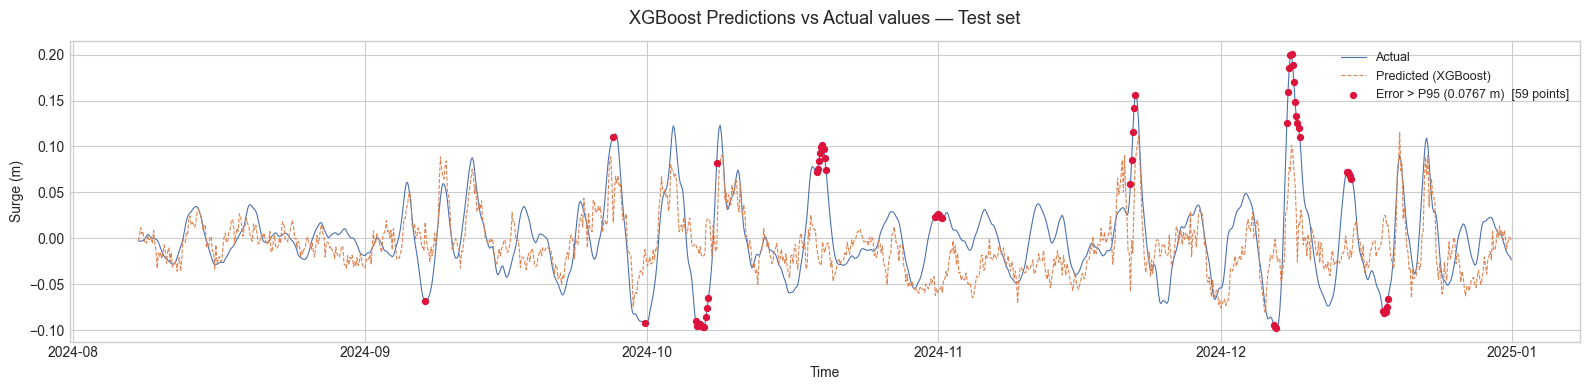

In [20]:
plot_predictions_vs_actual(
    y_surge_test, y_pred_test,
    title='XGBoost Predictions vs Actual values — Test set',
    ylabel='Surge (m)',
    save_path='plots/surge/surge_xgb_pred_vs_real.png',
)

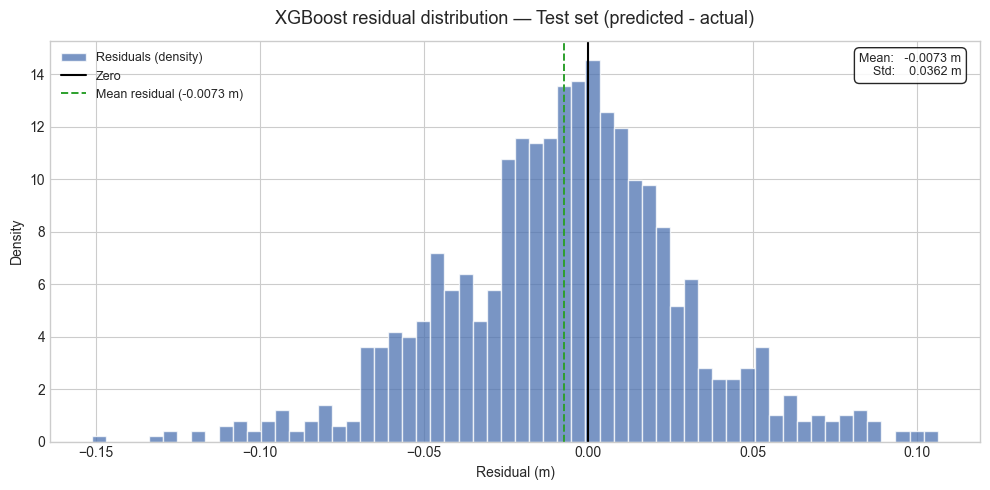

In [21]:
plot_residuals(
    y_surge_test, y_pred_test,
    title='XGBoost residual distribution — Test set (predicted - actual)',
    save_path='plots/surge/surge_xgb_residuals.png',
)

In [22]:
abs_errors = np.abs(y_pred_test - y_surge_test)

# Top 10 worst absolute errors 

df_errors = pd.DataFrame({
    'Actual (m)':    y_surge_test.values,
    'Predicted (m)': y_pred_test,
    'Abs. error (m)': abs_errors,
}, index=y_surge_test.index)

top10 = df_errors.nlargest(10, 'Abs. error (m)')

print('=== Top 10 worst absolute errors — XGBoost Test set ===')
print(f"  {'Date':<25} {'Actual (m)':>12} {'Predicted (m)':>14} {'Abs. error (m)':>16}")
print('  ' + '-' * 70)

for ts, row in top10.iterrows():
    print(f"  {str(ts):<25} {row['Actual (m)']:>12.4f} "
          f"{row['Predicted (m)']:>14.4f} {row['Abs. error (m)']:>16.4f}")

=== Top 10 worst absolute errors — XGBoost Test set ===
  Date                        Actual (m)  Predicted (m)   Abs. error (m)
  ----------------------------------------------------------------------
  2024-12-09 04:00:00             0.1255        -0.0256           0.1511
  2024-11-21 16:00:00             0.1152        -0.0160           0.1312
  2024-10-19 13:00:00             0.0991        -0.0296           0.1287
  2024-12-08 10:00:00             0.1996         0.0734           0.1262
  2024-10-19 10:00:00             0.0925        -0.0272           0.1197
  2024-11-21 10:00:00             0.0591        -0.0580           0.1171
  2024-12-08 04:00:00             0.1589         0.0476           0.1113
  2024-10-19 07:00:00             0.0838        -0.0260           0.1098
  2024-10-19 19:00:00             0.0972        -0.0113           0.1084
  2024-12-08 07:00:00             0.1854         0.0774           0.1079


# 5. Hyperparameter Tuning

## 5.1 Hyperparameter search and best parameters

In [23]:
SEARCH_RESULTS_PATH = 'models/surge/xgb_surge_search.json'

param_dist = {
    'n_estimators':     [100, 200, 300, 500, 700],
    'max_depth':        [3, 4, 5, 6, 7],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'reg_lambda':       [0, 0.1, 1.0, 5.0, 10.0],
    'reg_alpha':        [0, 0.1, 0.5, 1.0],
}

best_params, best_cv_mae = run_or_load_hyperparameter_search(
    X_surge_train, y_surge_train,
    param_dist=param_dist,
    results_path=SEARCH_RESULTS_PATH,
    n_iter=50,
    n_splits=5,
)


Search results loaded from models/surge/xgb_surge_search.json


In [24]:
print('=' * 55)
print('  BEST HYPERPARAMETERS — RandomizedSearchCV')
print('=' * 55)

for k, v in sorted(best_params.items()):
    print(f'  {k:<22}: {v}')
print(f'\n  Mean CV MAE (5 folds): {best_cv_mae:.5f} m')

print('=' * 55) 

  BEST HYPERPARAMETERS — RandomizedSearchCV
  colsample_bytree      : 1.0
  learning_rate         : 0.01
  max_depth             : 6
  min_child_weight      : 3
  n_estimators          : 500
  reg_alpha             : 0.1
  reg_lambda            : 10.0
  subsample             : 0.6

  Mean CV MAE (5 folds): 0.02614 m


## 5.2 Tuned model training and performance comparison

In [25]:
model_tuned = load_or_train_tuned(
    X_surge_train, y_surge_train,
    best_params=best_params,
    model_path='models/surge/xgb_surge_tuned.pkl',
)

model_tuned loaded from models/surge/xgb_surge_tuned.pkl


In [26]:
y_pred_baseline_train = model_baseline.predict(X_surge_train)
y_pred_baseline_test  = model_baseline.predict(X_surge_test)
y_pred_tuned_train = model_tuned.predict(X_surge_train)
y_pred_tuned_test = model_tuned.predict(X_surge_test)

rows = [
    compute_metrics(y_surge_train, y_pred_baseline_train, 'Baseline — Train'),
    compute_metrics(y_surge_test,  y_pred_baseline_test, 'Baseline — Test'),
    compute_metrics(y_surge_train, y_pred_tuned_train, 'Tuned — Train'),
    compute_metrics(y_surge_test,  y_pred_tuned_test, 'Tuned — Test'),
]

print_comparative_table(rows, title='COMPARATIVE METRICS — Baseline vs Tuned')
print_delta(rows[1], rows[3])


  COMPARATIVE METRICS — Baseline vs Tuned
  Model | Set         MAE (m)  RMSE (m)      R²
  ----------------------------------------------------
  Baseline — Train    0.00132   0.00176  0.9985
  Baseline — Test     0.02780   0.03689  0.3150
  ----------------------------------------------------
  Tuned — Train       0.01349   0.01748  0.8539
  Tuned — Test        0.02712   0.03563  0.3611

  Delta test (Tuned - Baseline):
  MAE:  -0.00068 m  (improvement)
  RMSE: -0.00126 m  (improvement)
  R²:   +0.04608    (improvement)


## 5.3 Predictions vs actual values — Baseline vs Tuned comparison

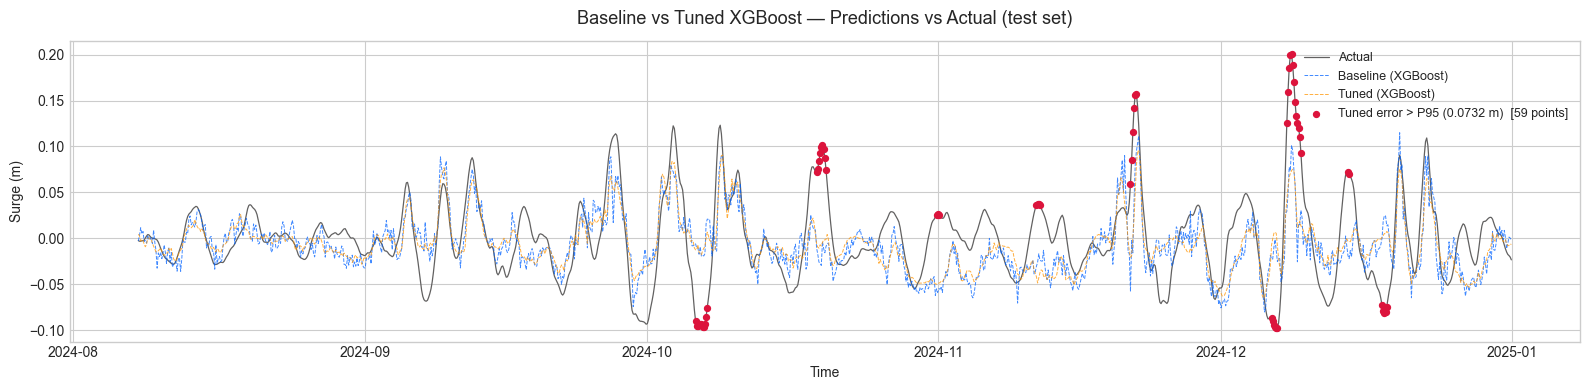

In [27]:
plot_baseline_vs_tuned_preds(
    y_surge_test, y_pred_baseline_test, y_pred_tuned_test,
    title='Baseline vs Tuned XGBoost — Predictions vs Actual (test set)',
    ylabel='Surge (m)',
    save_path='plots/surge/surge_baseline_vs_tuned_pred.png',
)

## 5.4 Visual comparison of test set metrics

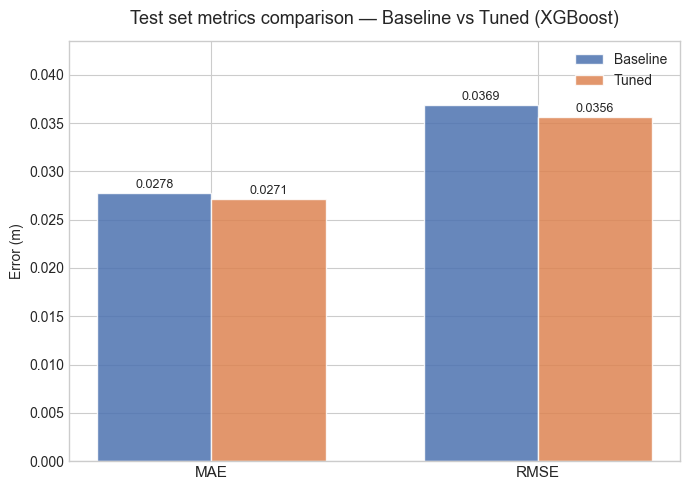

In [28]:
plot_metrics_comparison(
    baseline_mae=rows[1]['MAE (m)'],
    baseline_rmse=rows[1]['RMSE (m)'],
    tuned_mae=rows[3]['MAE (m)'],
    tuned_rmse=rows[3]['RMSE (m)'],
    title='Test set metrics comparison — Baseline vs Tuned (XGBoost)',
    save_path='plots/surge/surge_xgb_baseline_vs_tuned.png',
    layout='grouped',
)

# 6. SHAP Analysis

## 6.1 SHAP values computation

In [30]:
try:
    model_tuned
except NameError:
    model_tuned = joblib.load('models/surge/xgb_surge_tuned.pkl')
    print('model_tuned reloaded from disk.')

explainer = shap.TreeExplainer(model_tuned)

# shape values ​​for each feature of each observation
shap_values = explainer.shap_values(X_surge_test, check_additivity=False)

# overall shape values
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_surge_test.values,
    feature_names=list(X_surge_test.columns),
)

print(f'shap_values shape:  {shap_values.shape}')
print(f'Base value (E[f]):  {explainer.expected_value:.6f}')

shap_values shape:  (1169, 798)
Base value (E[f]):  0.000059


## 6.2 Summary plot (beeswarm)

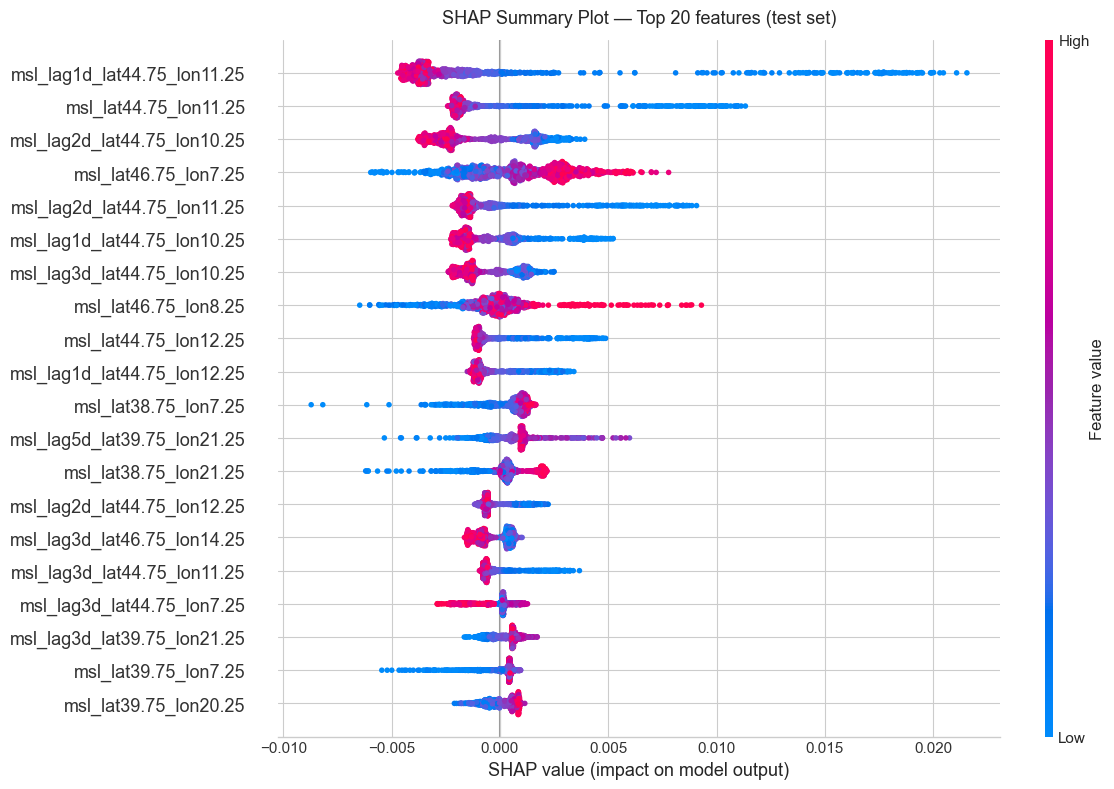

In [31]:

plot_shap_summary_beeswarm(
    shap_values, X_surge_test.values, list(X_surge_test.columns),
    title='SHAP Summary Plot — Top 20 features (test set)',
    save_path='plots/surge/shap_summary_beeswarm.png',
    max_display=20,
)

## 6.3 Feature importance ranking

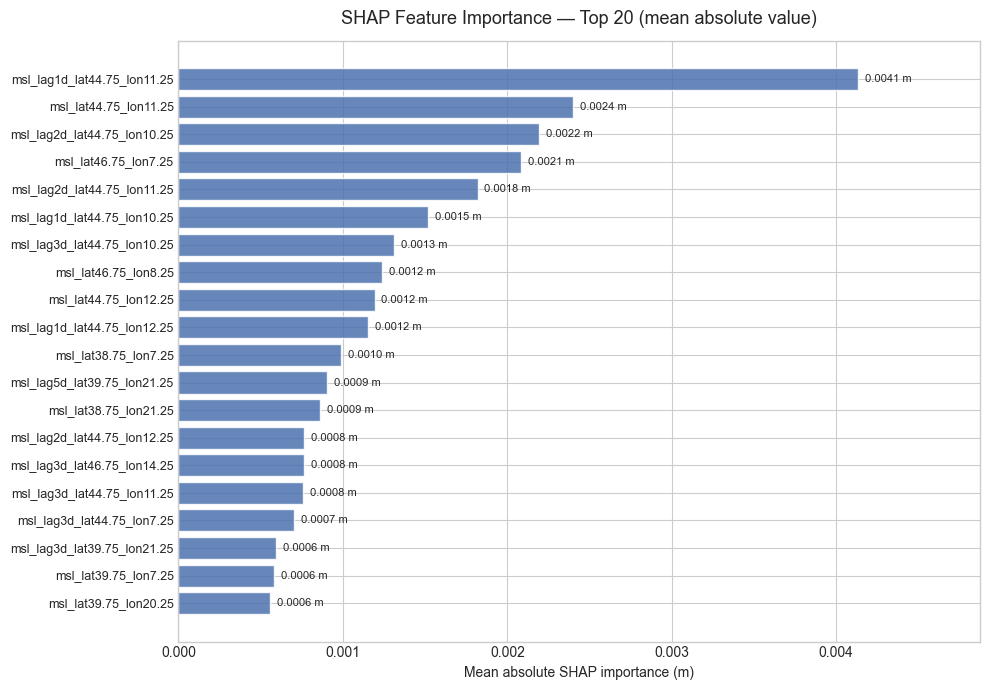

In [32]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_names = list(X_surge_test.columns)

plot_shap_importance_bar(
    mean_abs_shap, feature_names,
    title='SHAP Feature Importance — Top 20 (mean absolute value)',
    save_path='plots/surge/shap_importance_bar.png',
    top_n=20,
)

## 6.4 Waterfall plots

=== Extreme event ===
 Date: 2024-12-08 13:00:00
 Actual value: 0.2003 m
 Predicted value: 0.0737 m
 Absolute error: 0.1266 m


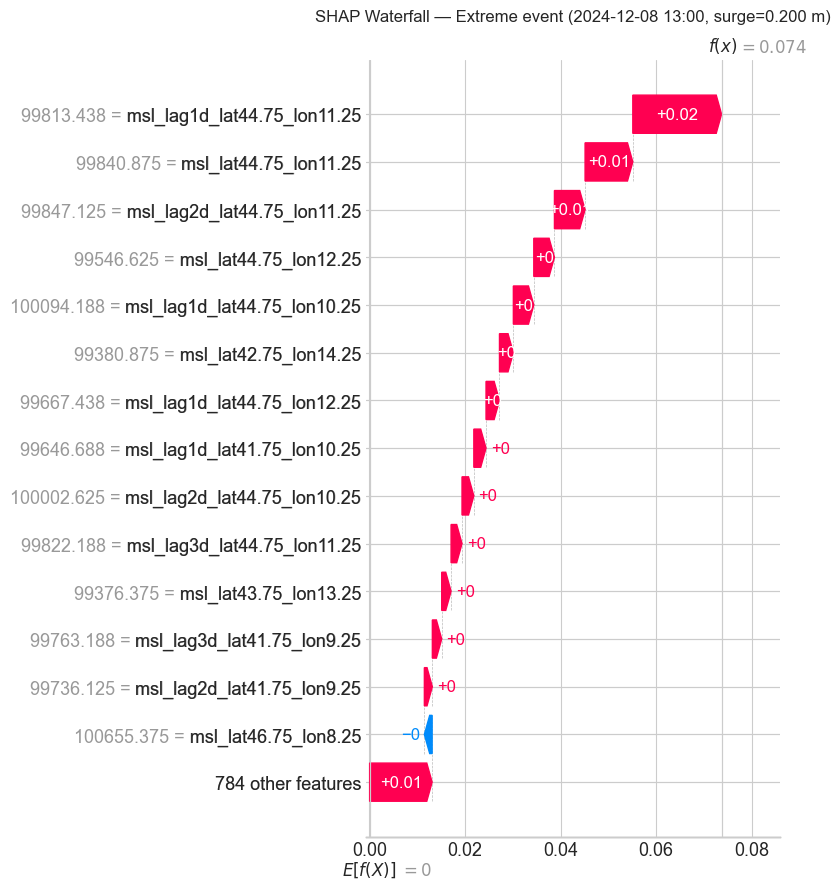

In [33]:

idx_extreme  = int(np.argmax(y_surge_test.values))
date_extreme = y_surge_test.index[idx_extreme]
real_extreme = y_surge_test.iloc[idx_extreme]
pred_extreme = y_pred_tuned_test[idx_extreme]
err_extreme  = abs(real_extreme - pred_extreme)

print('=== Extreme event ===')
print(f' Date: {date_extreme}')
print(f' Actual value: {real_extreme:.4f} m')
print(f' Predicted value: {pred_extreme:.4f} m')
print(f' Absolute error: {err_extreme:.4f} m')

plot_shap_waterfall(
    shap_explanation, idx_extreme,
    title=(
        f'SHAP Waterfall — Extreme event ({date_extreme.strftime("%Y-%m-%d %H:%M")}, '
        f'surge={real_extreme:.3f} m)'
    ),
    save_path='plots/surge/shap_waterfall_extreme.png',
    max_display=15,
)

=== Median prediction ===
 y_surge_test median: -0.0026 m
 Date: 2024-08-07 22:00:00
 Actual value: -0.0026 m
 Predicted value: 0.0044 m
 Absolute error: 0.0070 m


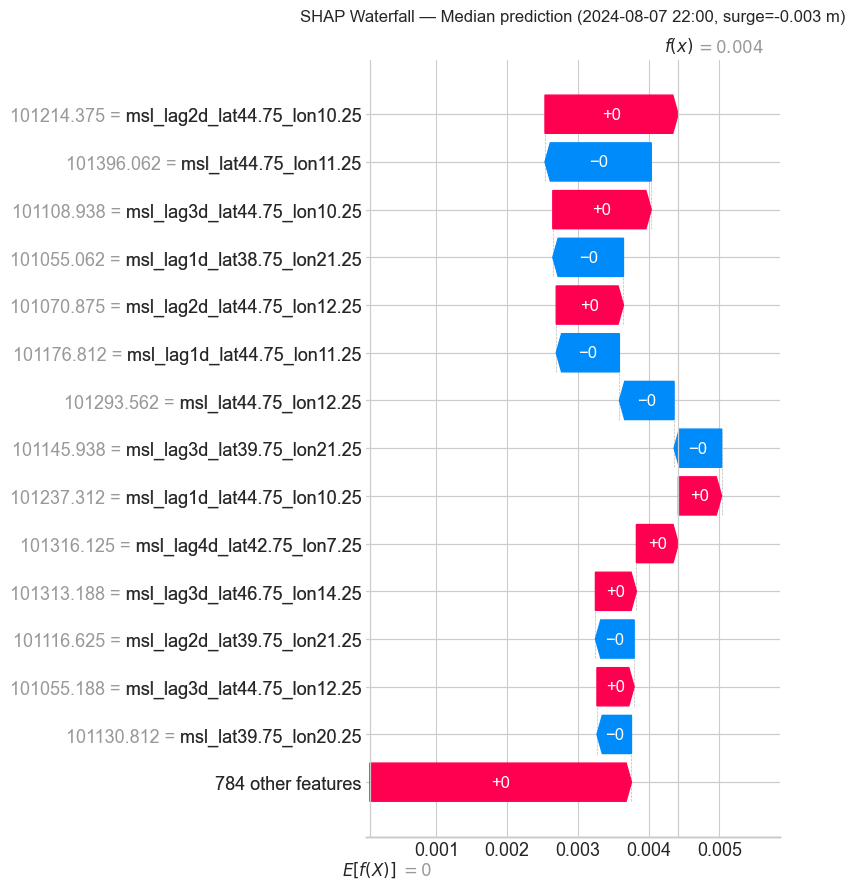

In [34]:

median_val  = float(np.median(y_surge_test.values))
idx_median  = int(np.argmin(np.abs(y_surge_test.values - median_val)))
date_median = y_surge_test.index[idx_median]
real_median = y_surge_test.iloc[idx_median]
pred_median = y_pred_tuned_test[idx_median]
err_median  = abs(real_median - pred_median)

print('=== Median prediction ===')
print(f' y_surge_test median: {median_val:.4f} m')
print(f' Date: {date_median}')
print(f' Actual value: {real_median:.4f} m')
print(f' Predicted value: {pred_median:.4f} m')
print(f' Absolute error: {err_median:.4f} m')

plot_shap_waterfall(
    shap_explanation, idx_median,
    title=(
        f'SHAP Waterfall — Median prediction ({date_median.strftime("%Y-%m-%d %H:%M")}, '
        f'surge={real_median:.3f} m)'
    ),
    save_path='plots/surge/shap_waterfall_median.png',
    max_display=15,
)

## 6.5 Spatial importance map


In [35]:
import re

pat = re.compile(r'^(.+)_lat([\d.\-]+)_lon([\d.\-]+)$')
feature_names = list(X_surge_test.columns)
grid_col_idx = {}
for col_i, fname in enumerate(feature_names):
    m = pat.match(fname)
    if not m:
        continue
    lat, lon = float(m.group(2)), float(m.group(3))
    grid_col_idx.setdefault((lat, lon), []).append(col_i)

mean_abs    = np.abs(shap_values).mean(axis=0)
grid_points = sorted(grid_col_idx.keys())
grid_imp    = np.array([mean_abs[grid_col_idx[pt]].sum() for pt in grid_points])
grid_lats   = np.array([pt[0] for pt in grid_points])
grid_lons   = np.array([pt[1] for pt in grid_points])

print(f'Adriatic grid points found: {len(grid_points)}')
print(f'Importance min: {grid_imp.min():.4f}  max: {grid_imp.max():.4f}')

plot_shap_geo_importance(
    grid_lats, grid_lons, grid_imp,
    title='Aggregated SHAP importance per grid point — surge_pressures',
    save_path='plots/surge/shap_geo_importance.png',
    venice_grid_lat=45.75, venice_grid_lon=12.25,
    lon_range=(8, 24), lat_range=(36, 49),
)

Adriatic grid points found: 133
Importance min: 0.0000  max: 0.0094


In [36]:
print_final_summary(
    title='XGBoost Surge Model',
    dataset_info=(
        f'  Period:       2019 + 2024 (4-year gap: 2020-2023)\n'
        f'  Train set:    {y_surge_train.index.min().strftime("%Y-%m-%d")} → '
        f'{y_surge_train.index.max().strftime("%Y-%m-%d")}  ({len(y_surge_train):,} samples)\n'
        f'  Test set:     {y_surge_test.index.min().strftime("%Y-%m-%d")} → '
        f'{y_surge_test.index.max().strftime("%Y-%m-%d")}  ({len(y_surge_test):,} samples)\n'
        f'  Features:     {X_surge_train.shape[1]}  (MSL + lags * 107 Adriatic grid points)\n'
        f'  Target:       surge at Venice (45.75N, 12.25E)'
    ),
    metrics=[
        compute_metrics(y_surge_train, y_pred_baseline_train, 'Baseline — Train'),
        compute_metrics(y_surge_test,  y_pred_baseline_test,  'Baseline — Test'),
        compute_metrics(y_surge_train, y_pred_tuned_train,    'Tuned    — Train'),
        compute_metrics(y_surge_test,  y_pred_tuned_test,     'Tuned    — Test'),
    ],
    top_shap_lines=[
        '1. msl_lag1d_lat44.75_lon11.25   →  0.0042 m  (Po Delta, lag 1d)',
        '2. msl_lag2d_lat44.75_lon11.25   →  0.0026 m  (Po Delta, lag 2d)',
        '3. msl_lag2d_lat44.75_lon10.25   →  0.0022 m  (W. Adriatic, lag 2d)',
        '4. msl_lag1d_lat44.75_lon12.25   →  0.0019 m  (N. Adriatic, lag 1d)',
        '5. msl_lag1d_lat44.75_lon10.25   →  0.0016 m  (W. Adriatic, lag 1d)',
    ],
)


  FINAL SUMMARY — XGBoost Surge Model

  Dataset
  ------------------------------------------------------------
  Period:       2019 + 2024 (4-year gap: 2020-2023)
  Train set:    2019-01-01 → 2024-08-07  (4,674 samples)
  Test set:     2024-08-07 → 2024-12-31  (1,169 samples)
  Features:     798  (MSL + lags * 107 Adriatic grid points)
  Target:       surge at Venice (45.75N, 12.25E)

  Model performance
  ------------------------------------------------------------
  Model                     MAE (m)   RMSE (m)       R²
  ------------------------------------------------------------
  Baseline — Train          0.00132    0.00176   0.9985
  Baseline — Test           0.02780    0.03689   0.3150
  ------------------------------------------------------------
  Tuned    — Train          0.01349    0.01748   0.8539
  Tuned    — Test           0.02712    0.03563   0.3611
  ------------------------------------------------------------

  Top SHAP features
  ------------------------------------